In [63]:
result_csv_path = "/home/Til/Downloads/combined_resolver.csv"
input_csv_path = "/home/Til/Downloads/resolver.csv"

In [64]:
import pandas as pd

df_res = pd.read_csv(result_csv_path)
df_in = pd.read_csv(input_csv_path)

merge = pd.merge(df_res, df_in, how="left", left_on=["resolverIP"], right_on=["queried_ip"])
merge.head()

,resolverIP,requestingIPs,qmin,response,protocol,queried_ip,replying_ip,backend_resolver,timestamp_request,resolver_type,...,queried_ip_org,replying_ip_org,backend_resolver_country,backend_resolver_asn,backend_resolver_prefix,backend_resolver_org,scan_date,queried_ip_uint32,replying_ip_uint32,backend_resolver_uint32
0,112.169.114.25,112.169.114.25;NONE,2,[23.22.21.20.19.18.17.16.15.14.13.12.11.10.9.8...,udp,112.169.114.25,112.169.114.25,112.169.114.25,2026-03-28 01:47:31.635129,Resolver,...,KIXS-AS-KR Korea Telecom,KIXS-AS-KR Korea Telecom,KOR,4766.0,112.168.0.0/13,KIXS-AS-KR Korea Telecom,2026-03-28,1890152985,1890152985,1890152985
1,119.59.114.4,119.59.114.4,0,[23.22.21.20.19.18.17.16.15.14.13.12.11.10.9.8...,udp,119.59.114.4,119.59.114.4,119.59.114.4,2026-03-28 06:40:20.412744,Resolver,...,METRABYTE-TH 453 Ladplacout Jorakhaebua,METRABYTE-TH 453 Ladplacout Jorakhaebua,THA,56067.0,119.59.96.0/19,METRABYTE-TH 453 Ladplacout Jorakhaebua,2026-03-28,2000384516,2000384516,2000384516
2,211.33.140.1,211.33.140.1,0,[23.22.21.20.19.18.17.16.15.14.13.12.11.10.9.8...,udp,211.33.140.1,211.33.140.1,211.33.140.1,2026-03-28 06:26:47.290743,Resolver,...,KIXS-AS-KR Korea Telecom,KIXS-AS-KR Korea Telecom,KOR,4766.0,211.33.128.0/17,KIXS-AS-KR Korea Telecom,2026-03-28,3542191105,3542191105,3542191105
3,155.137.125.158,NONE;155.137.125.158,2,[23.22.21|20.19.18.17|16.15.14.13|12.11.10.9|8...,udp,155.137.125.158,155.137.125.158,155.137.125.158,2026-03-28 07:52:08.096775,Resolver,...,RADIUSTELECOMS-AS-AP RADIUS TELECOMS,RADIUSTELECOMS-AS-AP RADIUS TELECOMS,PHL,55821.0,155.137.124.0/22,RADIUSTELECOMS-AS-AP RADIUS TELECOMS,2026-03-28,2609479070,2609479070,2609479070
4,210.117.49.4,NONE,-1,[timeout:115],udp,210.117.49.4,210.117.49.4,210.117.49.4,2026-03-28 06:38:08.372754,Resolver,...,SKB-AS SK Broadband Co Ltd,SKB-AS SK Broadband Co Ltd,KOR,9318.0,210.117.0.0/18,SKB-AS SK Broadband Co Ltd,2026-03-28,3530895620,3530895620,3530895620


In [ ]:
counts = (
    merge.value_counts(["queried_ip_country", "qmin"])
      .reset_index(name="count")
)
pivot = counts.pivot(index="queried_ip_country", columns="qmin", values="count").fillna(0)

total = pivot.sum(axis=1)
res = pd.DataFrame({
    "ratio_full_qmin": pivot[1] / total * 100,
    "ratio_ambigious_qmin": (pivot[1] + pivot[2]) / total * 100
}).reset_index()


import plotly.graph_objects as go
from plotly.subplots import make_subplots

import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=[
        "Full QMIN implementation",
        "Ambiguous QMIN implementation"
    ]
)

fig.add_trace(
    go.Choropleth(
        locations=res["queried_ip_country"],
        z=res["ratio_full_qmin"],
        coloraxis="coloraxis"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Choropleth(
        locations=res["queried_ip_country"],
        z=res["ratio_ambigious_qmin"],
        coloraxis="coloraxis"
    ),
    row=1, col=2
)

fig.update_layout(
    coloraxis=dict(
        colorscale="Reds",
        colorbar_title="% of total <br> Resolver"
    ),
    width=1800,
    height=800
)
fig.write_html("map.html")
fig.show()

## TOP 50 QMIN Countries

This graph shows the Top 50 Countries implementing QMIN. For the first Graph, ambiguous resolver (resolver that sometimes perform QMIN and sometimes don't) are counted as non-qmin resolver.

### By total amount of QMIN resolver

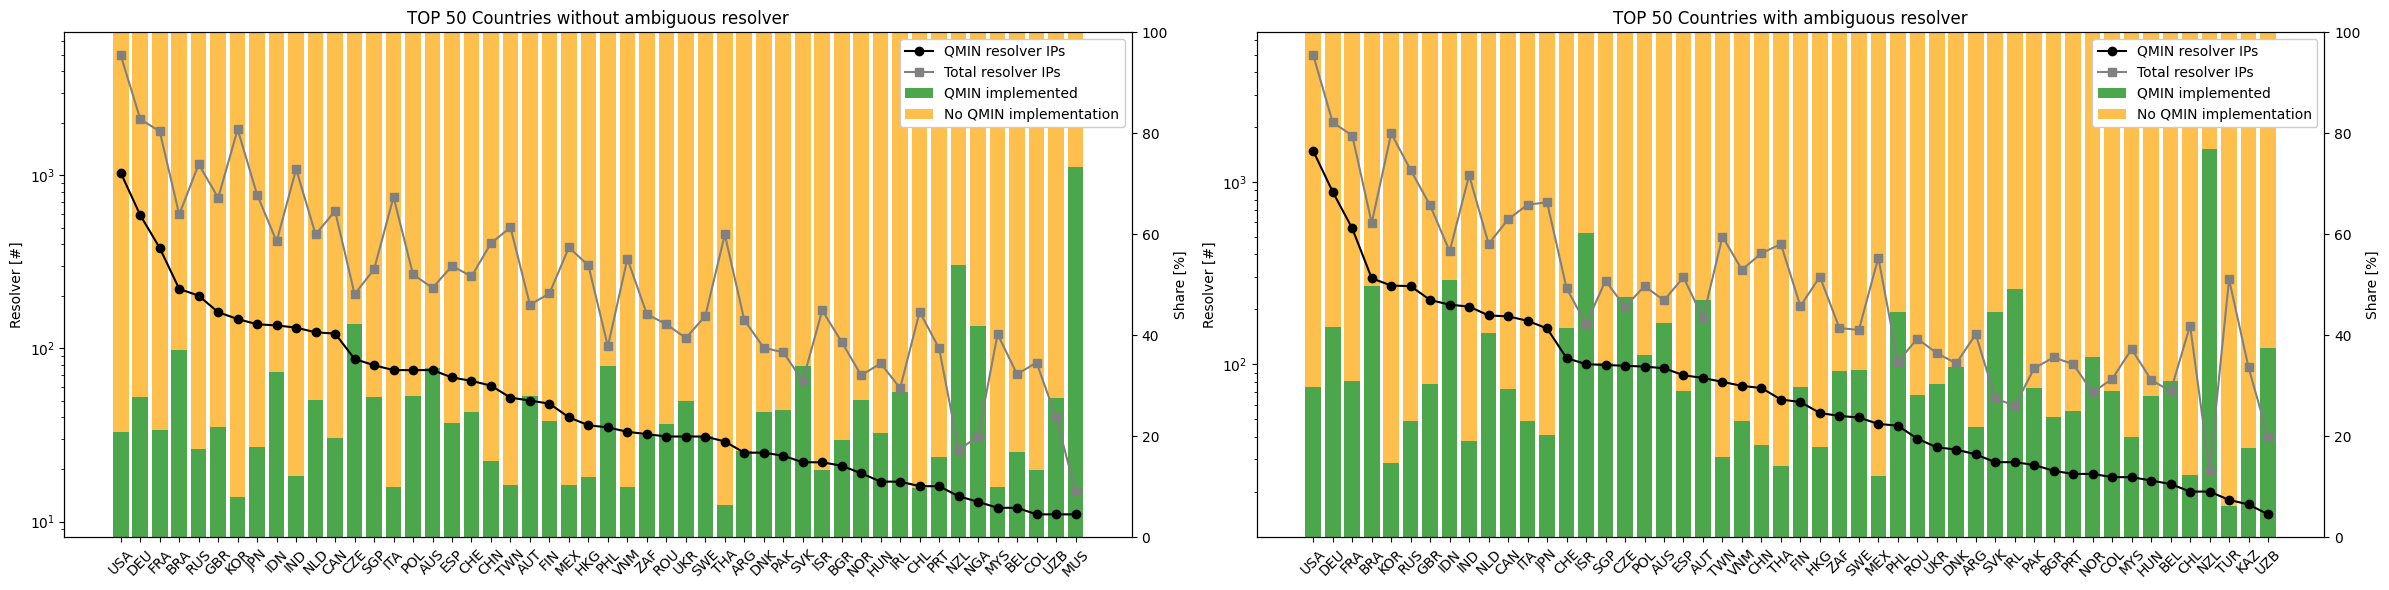

In [66]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(24, 6))

resolver_to_show = 50

top_qmin = pivot[1].sort_values(ascending=False)[:resolver_to_show]
top_total = total[top_qmin.index]

top_percentage = top_qmin / top_total * 100

x = np.arange(resolver_to_show)

# plot 1 (left)
ax1 = axes[0]
# Left axis: line plots
ax1.plot(
    x, pivot[1].sort_values(ascending=False)[:resolver_to_show],
    marker="o",
    color="black",
    label="QMIN resolver IPs"
)

ax1.plot(
    x, top_total,
    marker="s",
    color="gray",
    label="Total resolver IPs"
)

ax1.set_yscale("log")
ax1.set_ylabel("Resolver [#]")

# Right axis: stacked bars
ax1_r = ax1.twinx()

ax1_r.bar(
    x,
    top_percentage,
    color="green",
    alpha=0.7,
    label="QMIN implemented"
)

ax1_r.bar(
    x,
    100 - top_percentage,
    bottom=top_percentage,
    color="orange",
    alpha=0.7,
    label="No QMIN implementation"
)

ax1_r.set_ylim(0, 100)
ax1_r.set_ylabel("Share [%]")

# X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(top_qmin.index, rotation=45)

ax1.set_zorder(2)
ax1_r.set_zorder(1)
ax1.patch.set_visible(False)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax1_r.get_legend_handles_labels()

legend_ax1 = ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=1.0
)
legend_ax1.set_zorder(1000)
plt.title("TOP 50 Countries without ambiguous resolver")


#amb_qmin = pd.merge(pivot[1], pivot[2], on=["queried_ip_country"])
amb_qmin = pivot[1].add(pivot[2], fill_value=0).sort_values(ascending=False)[:resolver_to_show]
amb_top_total = total[amb_qmin.index]

amb_top_percentage = amb_qmin / amb_top_total * 100

# plot 2 (right)
ax2 = axes[1]
# Left axis: line plots
ax2.plot(
    x, amb_qmin,
    marker="o",
    color="black",
    label="QMIN resolver IPs"
)

ax2.plot(
    x, amb_top_total,
    marker="s",
    color="gray",
    label="Total resolver IPs"
)

ax2.set_yscale("log")
ax2.set_ylabel("Resolver [#]")

# Right axis: stacked bars
ax2_r = ax2.twinx()

ax2_r.bar(
    x,
    amb_top_percentage,
    color="green",
    alpha=0.7,
    label="QMIN implemented"
)

ax2_r.bar(
    x,
    100 - amb_top_percentage,
    bottom=amb_top_percentage,
    color="orange",
    alpha=0.7,
    label="No QMIN implementation"
)

ax2_r.set_ylim(0, 100)
ax2_r.set_ylabel("Share [%]")

# X-axis
ax2.set_xticks(x)
ax2.set_xticklabels(amb_qmin.index, rotation=45)

ax2.set_zorder(2)
ax2_r.set_zorder(1)
ax2.patch.set_visible(False)

# Combined legend
handles1, labels1 = ax2.get_legend_handles_labels()
handles2, labels2 = ax2_r.get_legend_handles_labels()

legend_ax2 = ax2.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=1.0
)
legend_ax2.set_zorder(1000)

plt.tight_layout()
plt.title("TOP 50 Countries with ambiguous resolver")
plt.show()

### By ratio between QMIN resolver and total amount of resolver

As there are some Countries with very few resolvers this plot can be kinda useless

In [67]:

ratio_full_qmin = (pivot[1] / total * 100).sort_values(ascending=False).head(resolver_to_show),
ratio_ambigious_qmin = ((pivot[1] + pivot[2]) / total * 100).sort_values(ascending=False).head(resolver_to_show)



print(ratio_ambigious_qmin)

queried_ip_country
AND    100.000000
BEN    100.000000
ATG    100.000000
CUW    100.000000
DMA    100.000000
COM    100.000000
GNB    100.000000
MDV    100.000000
IMN    100.000000
HTI    100.000000
VIR    100.000000
UGA     85.714286
NZL     76.923077
GMB     75.000000
MUS     73.333333
LUX     68.750000
RWA     66.666667
ISR     60.240964
KHM     60.000000
PSE     60.000000
ZWE     60.000000
BLZ     60.000000
IDN     50.961538
AFG     50.000000
TKM     50.000000
SOM     50.000000
TUN     50.000000
TCD     50.000000
BRA     49.747899
IRL     49.152542
CZE     47.572816
AUT     46.927374
AGO     46.666667
PHL     44.660194
SVK     44.615385
EST     42.857143
AUS     42.410714
NGA     41.935484
SYR     41.666667
DEU     41.623407
CHE     41.379310
NLD     40.481400
BIH     40.000000
MWI     40.000000
TZA     37.500000
UZB     37.500000
POL     36.194030
VEN     35.714286
KEN     35.714286
NOR     35.714286
dtype: float64
